
 ACCURACY COMPARISION : 
 Decision Tree Accuracy : 0.6111111111111112
 Random Forest Accuracy : 0.6666666666666666

 DECISION TREE CONFUSION MATRIX : 
  [[29 16]
 [19 26]]

 RANDOM FOREST CONFUSION MATRIX : 
  [[27 18]
 [12 33]]


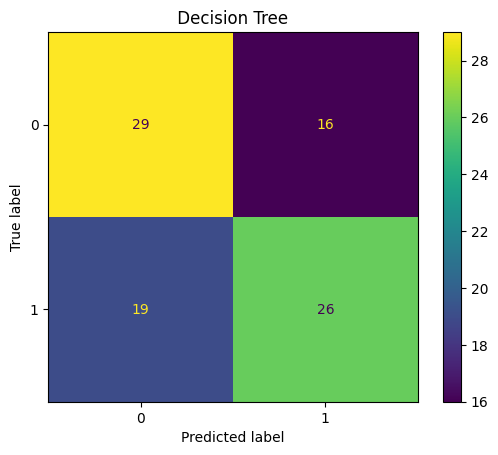

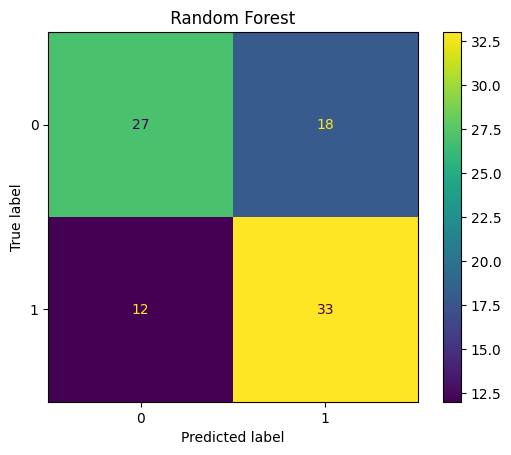


 CROSS VALIDATION ACCURACY :

 Decsion Tree :  0.5666666666666667

 Random Forest :  0.65


In [10]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

# GENERATE LARGER DATASET

np.random.seed(42)
random.seed(42)
n_samples=300

data={
'Weather': np.random. choice([ ' Sunny', 'Cloudy', 'Rainy'],n_samples),
'Soil': np.random. choice(['Dry', 'Moist', 'Wet' ], n_samples),
'Temperature': np. random. choice([ 'Hot', 'Mild', 'Cool'],n_samples),
'Humidity': np. random.choice(['High', 'Medium', 'Low' ],n_samples),
'Wind': np.random. choice(['Strong', 'Weak' ], n_samples),
'Fertilizer': np.random.choice(['Yes', 'No'], n_samples),
'CropType' : np.random. choice([ 'Wheat', 'Rice', 'Corn'],n_samples),
'Season': np.random.choice(['Kharif', 'Rabi', 'Summer' ],n_samples)
}
df=pd.DataFrame(data)

# TARGET WITH "NOISE"
def irrigation_rule(row):
  if row['Soil'] == 'Dry' and row['Weather'] != 'Rainy':
      base = 'Yes'
  elif row['Soil'] == 'Wet':
      base = 'No'
  else:
      base = random.choice(['Yes','No'])
# Add noise (flip label with 20% probability)
  if random.random() < 0.2:
    return 'No' if base == 'Yes' else 'Yes'
  return base
df['Irrigate'] = df.apply(irrigation_rule, axis=1)

# ENCODE DATA
le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])

# SPLIT DATA
  X= df.drop("Irrigate", axis=1)
  y=df["Irrigate"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

# DECISION TREE ( HIIGH VARIANCE )
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

# RANDOM FOREST ( VARIANCE REDUCTION )
rf_model= RandomForestClassifier(n_estimators=100,max_features='sqrt',random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

# ACCURACY COMPARISON
dt_acc= accuracy_score(y_test,y_pred_dt)
rf_acc=accuracy_score(y_test,y_pred_rf)

print("\n ACCURACY COMPARISION : ")
print(" Decision Tree Accuracy :",dt_acc)
print(" Random Forest Accuracy :",rf_acc)

# CONFUSION MATRIX
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

print("\n DECISION TREE CONFUSION MATRIX : \n ",cm_dt)
print("\n RANDOM FOREST CONFUSION MATRIX : \n ",cm_rf)

# VISUAL CONFUSION MATRIX
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title(" Decision Tree ")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)
plt.title(" Random Forest ")
plt.show()

# CROSS VALIDATION
dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print("\n CROSS VALIDATION ACCURACY :")
print("\n Decsion Tree : ",dt_cv.mean())
print("\n Random Forest : ",rf_cv.mean())


 ACCURACY COMPARISION : 
 Decision Tree Accuracy : 0.5066666666666667
 Random Forest Accuracy : 0.5466666666666666

 DECISION TREE CONFUSION MATRIX : 
  [[42 35]
 [39 34]]

 RANDOM FOREST CONFUSION MATRIX : 
  [[44 33]
 [35 38]]


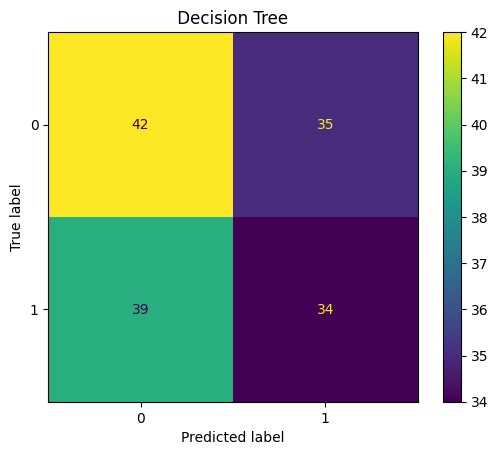

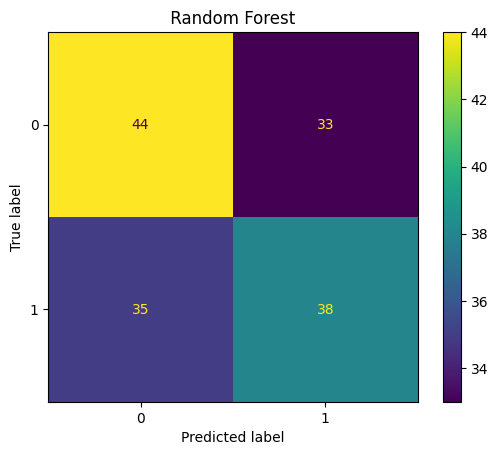


 CROSS VALIDATION ACCURACY :

 Decsion Tree :  0.516

 Random Forest :  0.502


In [11]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

# GENERATE LARGER DATASET

np.random.seed(42)
random.seed(42)
n_samples=500

data={
'Weather': np.random. choice([ ' Sunny', 'Cloudy', 'Rainy'],n_samples),
'Soil': np.random. choice(['Dry', 'Moist', 'Wet' ], n_samples),
'Temperature': np. random. choice([ 'Hot', 'Mild', 'Cool'],n_samples),
'Humidity': np. random.choice(['High', 'Medium', 'Low' ],n_samples),
'Wind': np.random. choice(['Strong', 'Weak' ], n_samples),
'Fertilizer': np.random.choice(['Yes', 'No'], n_samples),
'CropType' : np.random. choice([ 'Wheat', 'Rice', 'Corn'],n_samples),
'Season': np.random.choice(['Kharif', 'Rabi', 'Summer' ],n_samples)
}
df=pd.DataFrame(data)

# TARGET WITH "NOISE"
def irrigation_rule(row):
  if row['Soil'] == 'Dry' and row['Weather'] != 'Rainy':
      base = 'Yes'
  elif row['Soil'] == 'Wet':
      base = 'No'
  else:
      base = random.choice(['Yes','No'])
# Add noise (flip label with 50% probability)
  if random.random() < 0.5:
    return 'No' if base == 'Yes' else 'Yes'
  return base
df['Irrigate'] = df.apply(irrigation_rule, axis=1)

# ENCODE DATA
le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])

# SPLIT DATA
  X= df.drop("Irrigate", axis=1)
  y=df["Irrigate"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

# DECISION TREE ( HIIGH VARIANCE )
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

# RANDOM FOREST ( VARIANCE REDUCTION )
rf_model= RandomForestClassifier(n_estimators=100,max_features='sqrt',random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

# ACCURACY COMPARISON
dt_acc= accuracy_score(y_test,y_pred_dt)
rf_acc=accuracy_score(y_test,y_pred_rf)

print("\n ACCURACY COMPARISION : ")
print(" Decision Tree Accuracy :",dt_acc)
print(" Random Forest Accuracy :",rf_acc)

# CONFUSION MATRIX
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

print("\n DECISION TREE CONFUSION MATRIX : \n ",cm_dt)
print("\n RANDOM FOREST CONFUSION MATRIX : \n ",cm_rf)

# VISUAL CONFUSION MATRIX
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title(" Decision Tree ")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)
plt.title(" Random Forest ")
plt.show()

# CROSS VALIDATION
dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print("\n CROSS VALIDATION ACCURACY :")
print("\n Decsion Tree : ",dt_cv.mean())
print("\n Random Forest : ",rf_cv.mean())


 ACCURACY COMPARISION : 
 Decision Tree Accuracy : 0.47619047619047616
 Random Forest Accuracy : 0.5333333333333333

 DECISION TREE CONFUSION MATRIX : 
  [[48 55]
 [55 52]]

 RANDOM FOREST CONFUSION MATRIX : 
  [[52 51]
 [47 60]]


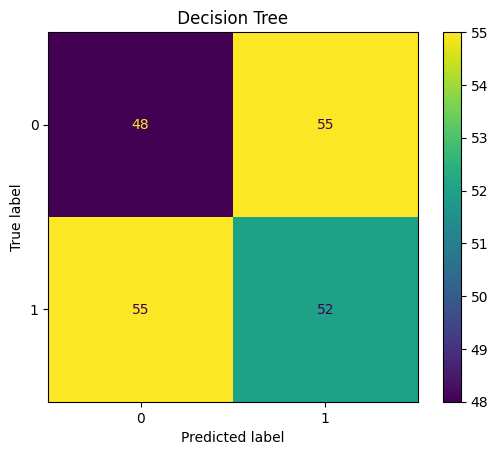

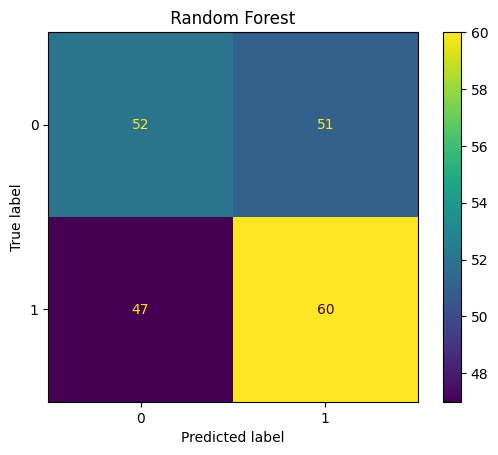


 CROSS VALIDATION ACCURACY :

 Decsion Tree :  0.4957142857142857

 Random Forest :  0.5442857142857143


In [12]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

# GENERATE LARGER DATASET

np.random.seed(42)
random.seed(42)
n_samples=700

data={
'Weather': np.random. choice([ ' Sunny', 'Cloudy', 'Rainy'],n_samples),
'Soil': np.random. choice(['Dry', 'Moist', 'Wet' ], n_samples),
'Temperature': np. random. choice([ 'Hot', 'Mild', 'Cool'],n_samples),
'Humidity': np. random.choice(['High', 'Medium', 'Low' ],n_samples),
'Wind': np.random. choice(['Strong', 'Weak' ], n_samples),
'Fertilizer': np.random.choice(['Yes', 'No'], n_samples),
'CropType' : np.random. choice([ 'Wheat', 'Rice', 'Corn'],n_samples),
'Season': np.random.choice(['Kharif', 'Rabi', 'Summer' ],n_samples)
}
df=pd.DataFrame(data)

# TARGET WITH "NOISE"
def irrigation_rule(row):
  if row['Soil'] == 'Dry' and row['Weather'] != 'Rainy':
      base = 'Yes'
  elif row['Soil'] == 'Wet':
      base = 'No'
  else:
      base = random.choice(['Yes','No'])
# Add noise (flip label with 70% probability)
  if random.random() < 0.7:
    return 'No' if base == 'Yes' else 'Yes'
  return base
df['Irrigate'] = df.apply(irrigation_rule, axis=1)

# ENCODE DATA
le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])

# SPLIT DATA
  X= df.drop("Irrigate", axis=1)
  y=df["Irrigate"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

# DECISION TREE ( HIIGH VARIANCE )
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

# RANDOM FOREST ( VARIANCE REDUCTION )
rf_model= RandomForestClassifier(n_estimators=100,max_features='sqrt',random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

# ACCURACY COMPARISON
dt_acc= accuracy_score(y_test,y_pred_dt)
rf_acc=accuracy_score(y_test,y_pred_rf)

print("\n ACCURACY COMPARISION : ")
print(" Decision Tree Accuracy :",dt_acc)
print(" Random Forest Accuracy :",rf_acc)

# CONFUSION MATRIX
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

print("\n DECISION TREE CONFUSION MATRIX : \n ",cm_dt)
print("\n RANDOM FOREST CONFUSION MATRIX : \n ",cm_rf)

# VISUAL CONFUSION MATRIX
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title(" Decision Tree ")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)
plt.title(" Random Forest ")
plt.show()

# CROSS VALIDATION
dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print("\n CROSS VALIDATION ACCURACY :")
print("\n Decsion Tree : ",dt_cv.mean())
print("\n Random Forest : ",rf_cv.mean())


 ACCURACY COMPARISION : 
 Decision Tree Accuracy : 0.5222222222222223
 Random Forest Accuracy : 0.4888888888888889

 DECISION TREE CONFUSION MATRIX : 
  [[23 23]
 [20 24]]

 RANDOM FOREST CONFUSION MATRIX : 
  [[25 21]
 [25 19]]


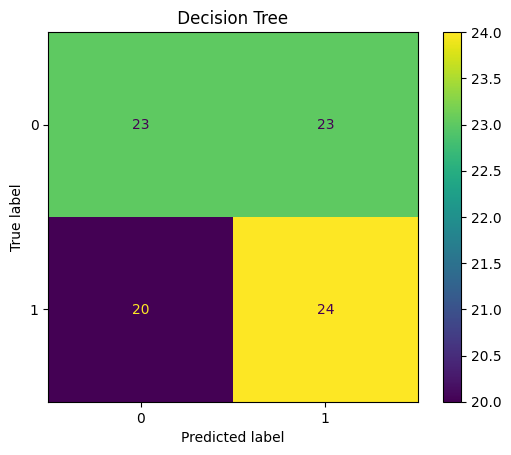

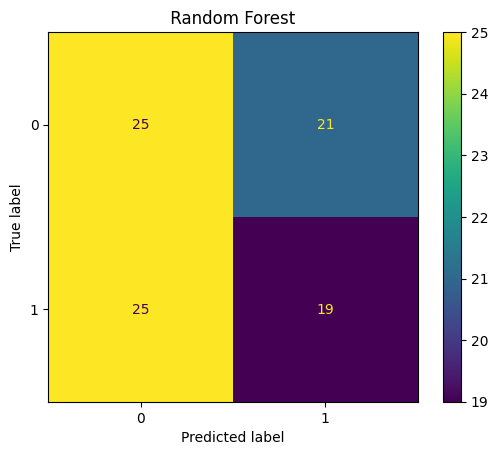


 CROSS VALIDATION ACCURACY :

 Decsion Tree :  0.5599999999999999

 Random Forest :  0.5933333333333334


In [13]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

# GENERATE LARGER DATASET

np.random.seed(50)
random.seed(50)
n_samples=300

data={
'Weather': np.random. choice([ ' Sunny', 'Cloudy', 'Rainy'],n_samples),
'Soil': np.random. choice(['Dry', 'Moist', 'Wet' ], n_samples),
'Temperature': np. random. choice([ 'Hot', 'Mild', 'Cool'],n_samples),
'Humidity': np. random.choice(['High', 'Medium', 'Low' ],n_samples),
'Wind': np.random. choice(['Strong', 'Weak' ], n_samples),
'Fertilizer': np.random.choice(['Yes', 'No'], n_samples),
'CropType' : np.random. choice([ 'Wheat', 'Rice', 'Corn'],n_samples),
'Season': np.random.choice(['Kharif', 'Rabi', 'Summer' ],n_samples)
}
df=pd.DataFrame(data)

# TARGET WITH "NOISE"
def irrigation_rule(row):
  if row['Soil'] == 'Dry' and row['Weather'] != 'Rainy':
      base = 'Yes'
  elif row['Soil'] == 'Wet':
      base = 'No'
  else:
      base = random.choice(['Yes','No'])
# Add noise (flip label with 20% probability)
  if random.random() < 0.2:
    return 'No' if base == 'Yes' else 'Yes'
  return base
df['Irrigate'] = df.apply(irrigation_rule, axis=1)

# ENCODE DATA
le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])

# SPLIT DATA
  X= df.drop("Irrigate", axis=1)
  y=df["Irrigate"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

# DECISION TREE ( HIIGH VARIANCE )
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

# RANDOM FOREST ( VARIANCE REDUCTION )
rf_model= RandomForestClassifier(n_estimators=100,max_features='sqrt',random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

# ACCURACY COMPARISON
dt_acc= accuracy_score(y_test,y_pred_dt)
rf_acc=accuracy_score(y_test,y_pred_rf)

print("\n ACCURACY COMPARISION : ")
print(" Decision Tree Accuracy :",dt_acc)
print(" Random Forest Accuracy :",rf_acc)

# CONFUSION MATRIX
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

print("\n DECISION TREE CONFUSION MATRIX : \n ",cm_dt)
print("\n RANDOM FOREST CONFUSION MATRIX : \n ",cm_rf)

# VISUAL CONFUSION MATRIX
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title(" Decision Tree ")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)
plt.title(" Random Forest ")
plt.show()

# CROSS VALIDATION
dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print("\n CROSS VALIDATION ACCURACY :")
print("\n Decsion Tree : ",dt_cv.mean())
print("\n Random Forest : ",rf_cv.mean())


 ACCURACY COMPARISION : 
 Decision Tree Accuracy : 0.6066666666666667
 Random Forest Accuracy : 0.67

 DECISION TREE CONFUSION MATRIX : 
  [[115  56]
 [ 62  67]]

 RANDOM FOREST CONFUSION MATRIX : 
  [[124  47]
 [ 52  77]]


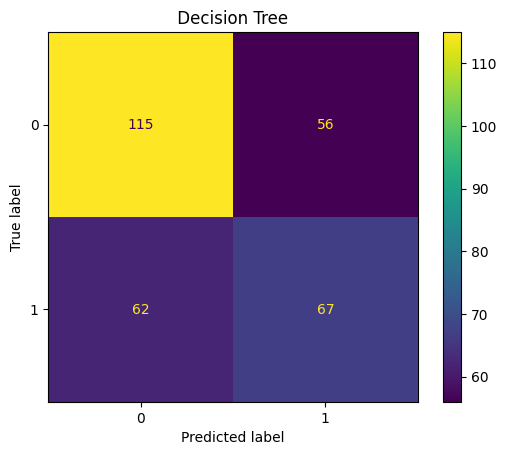

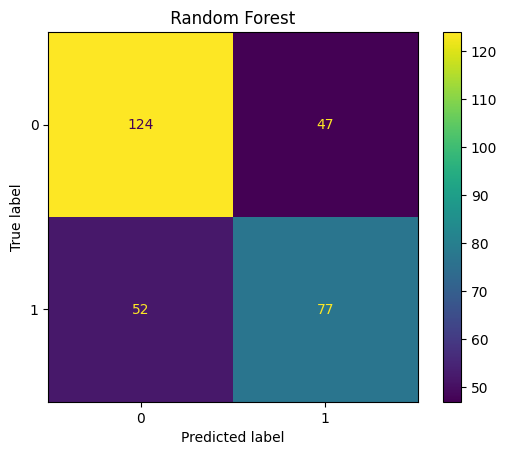


 CROSS VALIDATION ACCURACY :

 Decsion Tree :  0.599

 Random Forest :  0.6559999999999999


In [14]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

# GENERATE LARGER DATASET

np.random.seed(50)
random.seed(50)
n_samples=1000

data={
'Weather': np.random. choice([ ' Sunny', 'Cloudy', 'Rainy'],n_samples),
'Soil': np.random. choice(['Dry', 'Moist', 'Wet' ], n_samples),
'Temperature': np. random. choice([ 'Hot', 'Mild', 'Cool'],n_samples),
'Humidity': np. random.choice(['High', 'Medium', 'Low' ],n_samples),
'Wind': np.random. choice(['Strong', 'Weak' ], n_samples),
'Fertilizer': np.random.choice(['Yes', 'No'], n_samples),
'CropType' : np.random. choice([ 'Wheat', 'Rice', 'Corn'],n_samples),
'Season': np.random.choice(['Kharif', 'Rabi', 'Summer' ],n_samples)
}
df=pd.DataFrame(data)

# TARGET WITH "NOISE"
def irrigation_rule(row):
  if row['Soil'] == 'Dry' and row['Weather'] != 'Rainy':
      base = 'Yes'
  elif row['Soil'] == 'Wet':
      base = 'No'
  else:
      base = random.choice(['Yes','No'])
# Add noise (flip label with 20% probability)
  if random.random() < 0.2:
    return 'No' if base == 'Yes' else 'Yes'
  return base
df['Irrigate'] = df.apply(irrigation_rule, axis=1)

# ENCODE DATA
le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])

# SPLIT DATA
  X= df.drop("Irrigate", axis=1)
  y=df["Irrigate"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

# DECISION TREE ( HIIGH VARIANCE )
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

# RANDOM FOREST ( VARIANCE REDUCTION )
rf_model= RandomForestClassifier(n_estimators=100,max_features='sqrt',random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

# ACCURACY COMPARISON
dt_acc= accuracy_score(y_test,y_pred_dt)
rf_acc=accuracy_score(y_test,y_pred_rf)

print("\n ACCURACY COMPARISION : ")
print(" Decision Tree Accuracy :",dt_acc)
print(" Random Forest Accuracy :",rf_acc)

# CONFUSION MATRIX
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

print("\n DECISION TREE CONFUSION MATRIX : \n ",cm_dt)
print("\n RANDOM FOREST CONFUSION MATRIX : \n ",cm_rf)

# VISUAL CONFUSION MATRIX
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title(" Decision Tree ")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)
plt.title(" Random Forest ")
plt.show()

# CROSS VALIDATION
dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print("\n CROSS VALIDATION ACCURACY :")
print("\n Decsion Tree : ",dt_cv.mean())
print("\n Random Forest : ",rf_cv.mean())